In [ ]:
import os

import jax
import pickle
import numpy as np
import nifty.re as jft
import matplotlib.pyplot as plt
from aim_resolve import OptimizeKLConfig, SignalModel, TileModel, get_builders

jax.config.update("jax_enable_x64", True)

In [13]:
def latest_model_file(directory):
    import os
    import re

    max_file = None
    max_it = -1
    for filename in os.listdir(directory + '/files'):
        match = re.compile(r'(\d+)_mdl\.yml$').match(filename)
        if match:
            it = int(match.group(1))
            if it > max_it:
                max_it = it
                max_file = filename

    return directory + f'/files/{max_file}'


def plot_pspec(
        ax, 
        mdl, 
        smpls, 
        name='$s_{b}$', 
        ylim=None,
        xlabel=False, 
        ylabel=False,
):
    if isinstance(mdl, TileModel):
        pspecs = jft.mean(tuple(mdl.tiles.pspec(s) for s in smpls))
        x = np.arange(0, pspecs.shape[1])

        for i, s in enumerate(smpls):
            pspecs_s = mdl.tiles.pspec(s)
            for j in range(pspecs_s.shape[0]):
                if i == j == 0:
                    ax.loglog(x, pspecs_s[j], label=' reconstructed samples', c='gray', lw=0.25)
                else:
                    ax.loglog(x, pspecs_s[j], c='gray', lw=0.25)

        for j in range(pspecs.shape[0]):
            if j == 0:
                ax.loglog(x, pspecs[j], label=' reconstructed means', lw=2)
            else:
                ax.loglog(x, pspecs[j], lw=2)

        ax.legend()

    elif isinstance(smpls, jft.Samples):
        pspec = jft.mean(tuple(mdl.pspec(s) for s in smpls))
        x = np.arange(0, pspec.size)
    
        for i,s in enumerate(smpls):
            if i == 0:
                ax.loglog(x, mdl.pspec(s), label='reconstructed samples', c='gray', lw=0.25)
            else:
                ax.loglog(x, mdl.pspec(s), c='gray', lw=0.25)
        ax.loglog(x, pspec, label=' reconstructed mean', c='red', lw=2)
        ax.legend()
    else:
        pspec = mdl.pspec(smpls)
        x = np.arange(0, pspec.size)
        ax.loglog(x, pspec, c='red', lw=2)
 
    if xlabel:
        ax.set_xlabel('$|k|$')
    if ylabel:
        ax.set_ylabel('$P_s(|k|)$')
    ax.set_title(name)
    ax.set_xlim(1, x.size)
    if ylim != None:
        ax.set_ylim(ylim)

In [11]:
exp_dir = '/Users/rf/Development/packages/aim-resolve/steering/runs/eso_vi_1024l'
it = 2


    
exp_yml = latest_model_file(exp_dir)

optim_cfg = OptimizeKLConfig.from_file((exp_dir + '/files/base.yml', exp_yml), get_builders, 'total')
optim_cfg.sections['data.0']['fname'] = '/Users/rf/Development/packages/aim-resolve/steering/' + optim_cfg.sections['data.0']['fname']

sky_dct = [sec for sec in optim_cfg.sections if sec.startswith('sky')]


scm_models = {}
for sec in filter(lambda x: '.0' in x, sky_dct):
    sky_c = optim_cfg.instantiate_sec(sec)
    if isinstance(sky_c, SignalModel):
        scm_models[sec] = sky_c

with open(exp_dir + f'/opt/0_rec/last.pkl', "rb") as f:
    scm_samples, *_ = pickle.load(f)

print(scm_models.keys())


mcm_models = {}
for sec in filter(lambda x: f'.{it}' in x, sky_dct):
    sky_c = optim_cfg.instantiate_sec(sec)
    if isinstance(sky_c, (SignalModel, TileModel)):
        mcm_models[sec] = sky_c

with open(exp_dir + f'/opt/{it}_rec/last.pkl', "rb") as f:
    mcm_samples, *_ = pickle.load(f)

print(mcm_models.keys())

dict_keys(['sky_bg.0'])
dict_keys(['sky_bg.2', 'sky_o0.2', 'sky_o1.2', 'sky_o2.2', 'sky_t0.2'])


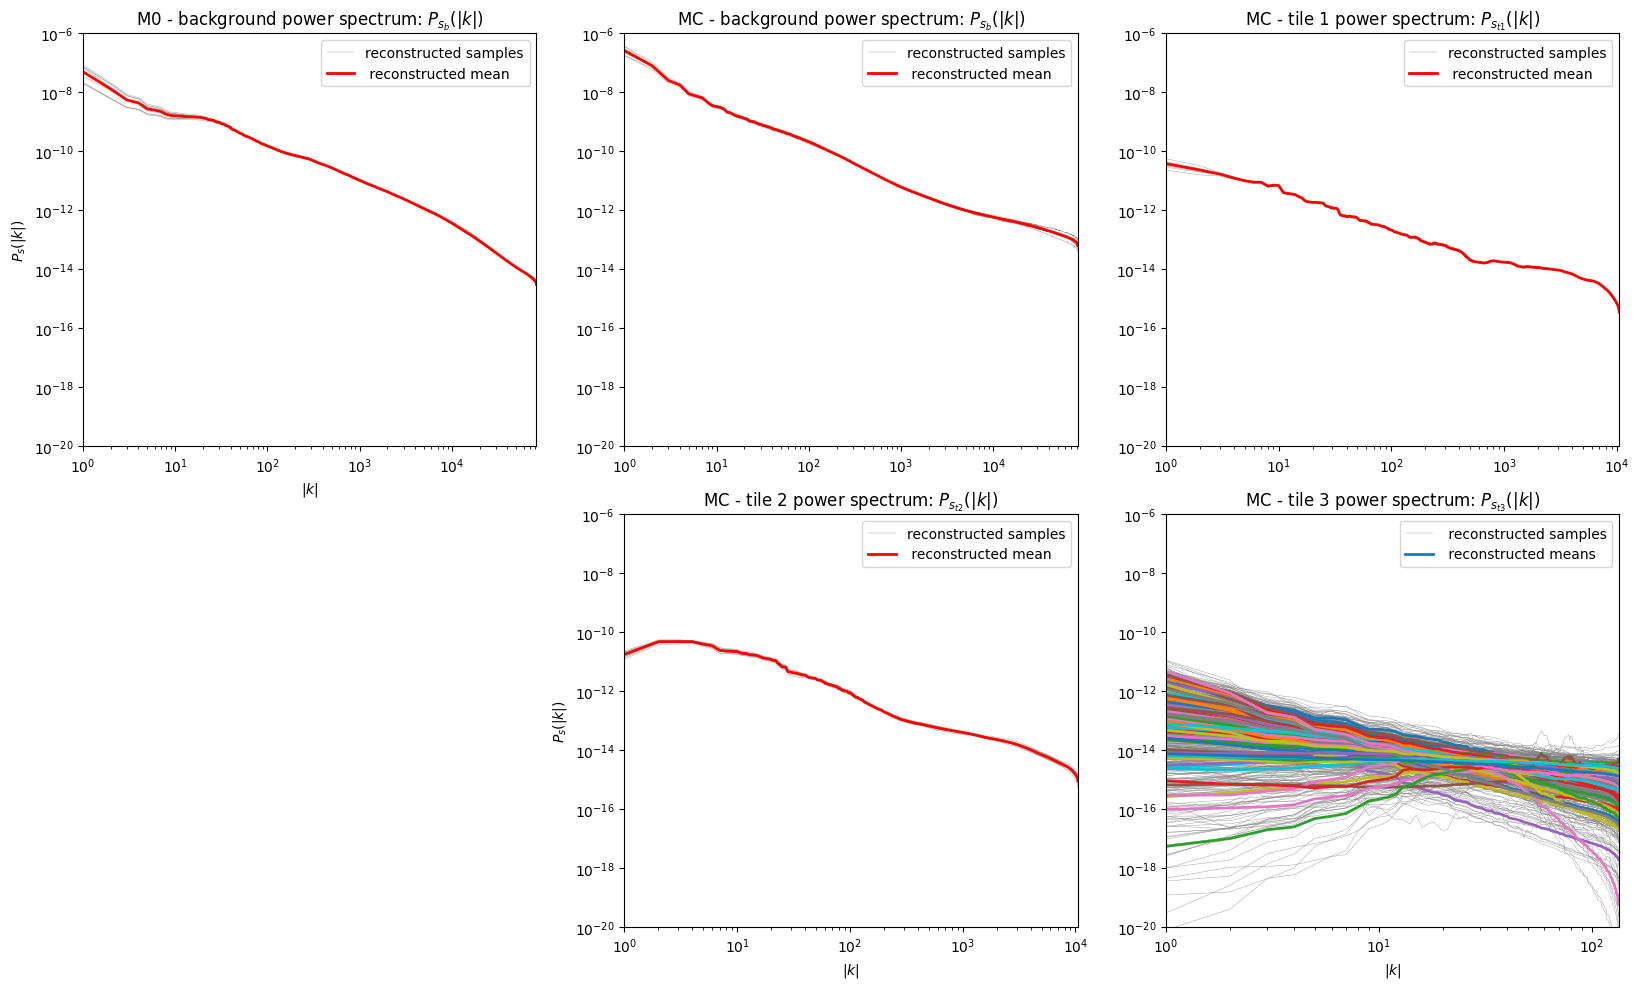

In [14]:
rows, cols = (2, 3)

fig = plt.figure(figsize=(5.5*cols, 5*rows))
axs = []
ylim = (1e-20, 1e-6)

md = scm_models['sky_bg.0']
axs.append(fig.add_subplot(rows, cols, 1))
plot_pspec(axs[-1], md, scm_samples, 'M0 - background power spectrum: $P_{s_b}(|k|)$', ylabel=True, xlabel=True, ylim=ylim)

md = mcm_models[f'sky_bg.{it}']
axs.append(fig.add_subplot(rows, cols, 2))
plot_pspec(axs[-1], md, mcm_samples, 'MC - background power spectrum: $P_{s_b}(|k|)$', ylim=ylim)

md = mcm_models[f'sky_o0.{it}']
axs.append(fig.add_subplot(rows, cols, 3))
plot_pspec(axs[-1], md, mcm_samples, 'MC - tile 1 power spectrum: $P_{s_{t1}}(|k|)$', ylim=ylim)

md = mcm_models[f'sky_o1.{it}']
axs.append(fig.add_subplot(rows, cols, 5))
plot_pspec(axs[-1], md, mcm_samples, 'MC - tile 2 power spectrum: $P_{s_{t2}}(|k|)$', ylabel=True, xlabel=True, ylim=ylim)

md = mcm_models[f'sky_t0.{it}']
axs.append(fig.add_subplot(rows, cols, 6))
plot_pspec(axs[-1], md, mcm_samples, 'MC - tile 3 power spectrum: $P_{s_{t3}}(|k|)$', xlabel=True, ylim=ylim)

fig.tight_layout()
plt.show() 
# plt.savefig('pw.jpeg')

\begin{table}[h]
\caption{Prior parameters of the SCM}              % title of Table
\label{tab:prior_scm}      % is used to refer this table in the text
\centering                                      % used for centering table
\begin{tabular}{c c c c}          % centered columns (4 columns)
\hline\hline                        % inserts double horizontal lines
SCM &  \\    % table heading
& mean & std \\
\hline                                   % inserts single horizontal line
    offset & 0.937 \\      % inserting body of the table
    zero mode &  0.887 \\
    fluctuations & 0.539  \\
    loglogavgslope & \\
    flexibility & \\
    asperity & \\
\hline                                             %inserts single line
\end{tabular}
\end{table}

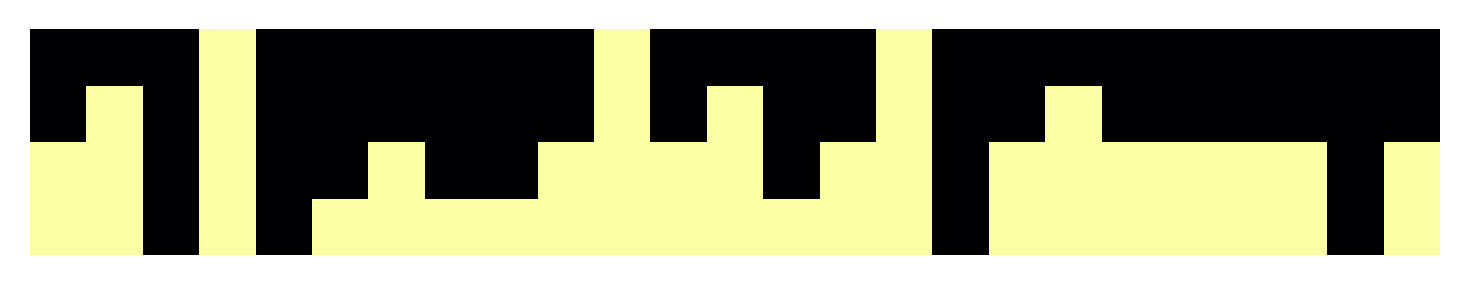

In [65]:
import numpy as np
from aim_resolve import plot_arrays

height = np.random.randint(0,5,25).tolist()
hplot = np.zeros((len(height), max(height)), dtype=int)
for i,h in enumerate(height):
    hplot[i, :h] = 5
plot_arrays(hplot, cbar=False, ticks=0)

34


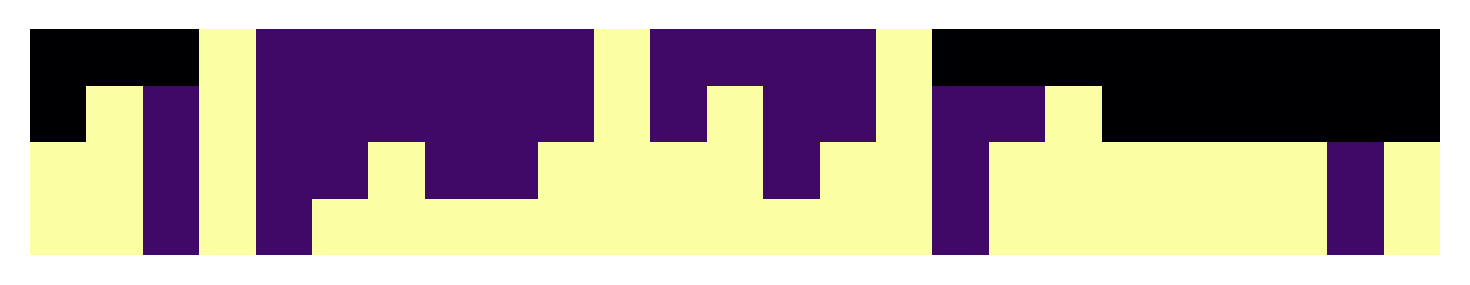

In [66]:
def trap(height) -> int:
    vol = 0
    idx = []
    p0 = 0
    p1 = len(height) - 1
    levels = range(1, max(height) + 1)
    for l in levels:
        while height[p0] < l:
           p0 += 1
        while height[p1] < l:
            p1 -= 1
        for i in range(p0, p1+1):
            if height[i] < l:
                vol += 1
                idx.append([i, l-1])
        
    return vol, idx


vol, idx = trap(height)
print(vol)

for i, j in idx:
    hplot[i, j] = 1
plot_arrays(hplot, cbar=False, ticks=0)